# AdaBoost — Manual Step-by-Step Implementation

## What is AdaBoost?
**AdaBoost (Adaptive Boosting)** builds an ensemble of weak learners (stumps — decision trees with max_depth=1) **sequentially**.
Each new stump focuses **more** on the samples that the previous stumps got wrong.

### Core Idea
```
Final prediction = sign( α₁·T₁(x) + α₂·T₂(x) + α₃·T₃(x) + ... )
```
Where:
- `Tᵢ(x)` = prediction of the i-th stump (+1 or -1)
- `αᵢ` = weight (importance) of the i-th stump — better stumps get higher weight
- `sign(...)` = final class label

### The 4-Step Loop (repeated for each stump)
| Step | What happens |
|------|-------------|
| 1 | **Weighted bootstrap** — sample rows by probability proportional to their weight |
| 2 | **Train a stump** on the sampled data |
| 3 | **Compute model weight α** = 0.5 × ln((1-error)/error) |
| 4 | **Update sample weights** — misclassified samples get higher weight |

This notebook runs **3 iterations manually** so you can see every intermediate value.


## Step 1: Imports

In [2]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

## Step 2: Create a Toy Dataset
10 samples, 2 features (X1, X2), binary label (0 or 1).
Small enough to trace every number by hand.


In [3]:
df = pd.DataFrame()

In [4]:
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [5]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


### Visualise the Dataset
Scatter plot — colour = class label. Two features, linearly overlapping → no single line separates them perfectly.

<Axes: xlabel='X1', ylabel='X2'>

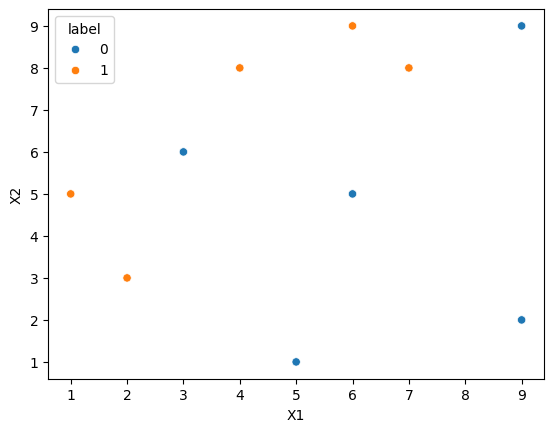

In [6]:
import seaborn as sns
sns.scatterplot(x=df['X1'],y=df['X2'],hue=df['label'])

---
## Iteration 1

### Step 3: Initialise Sample Weights
Every sample starts with equal weight = **1/N** (here 1/10 = 0.1).
AdaBoost uses these weights to decide which samples to focus on.


In [7]:
df['weights'] = 1/df.shape[0]

In [8]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


### Step 4: Imports for Decision Tree Stump
A **stump** is a Decision Tree with `max_depth=1` — it makes exactly one split on one feature.
Stumps are deliberately weak; their strength comes from combining many of them.


In [9]:
from sklearn.tree import DecisionTreeClassifier

In [10]:
dt1 = DecisionTreeClassifier(max_depth=1)

In [11]:
X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

### Step 5: Train Stump 1 (dt1) on the Original Data
Weighted bootstrap hasn't happened yet for the first stump —
we train directly on the original dataset (all weights equal).


In [12]:
# Step 2 - Train 1st model
dt1.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

### Visualise Stump 1 — Decision Tree Structure
With `max_depth=1` the tree has exactly one split node and two leaf nodes.

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

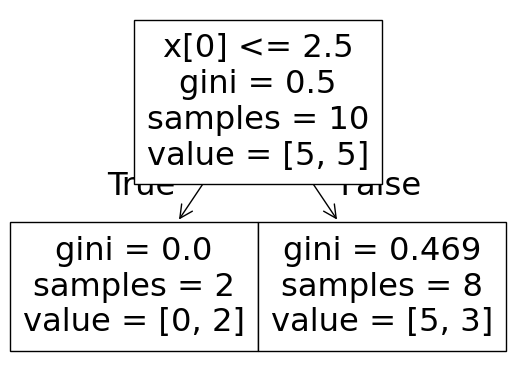

In [13]:
from sklearn.tree import plot_tree
plot_tree(dt1)

### Visualise Stump 1 — Decision Boundary
The boundary is a single horizontal or vertical line (one split = one axis-aligned line).

<Axes: >

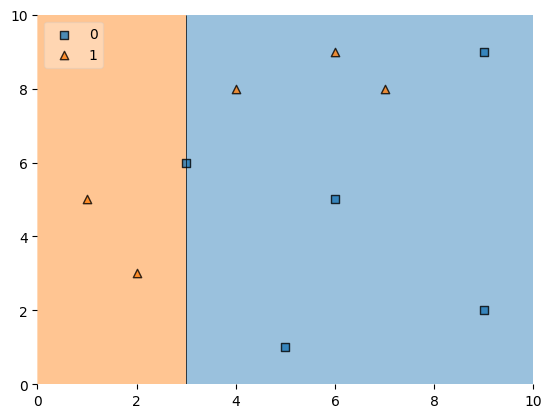

In [14]:
plot_decision_regions(X, y, clf=dt1, legend=2)

### Step 6: Get Stump 1 Predictions
Add predictions to the dataframe so we can see which samples were mis-classified.


In [15]:
df['y_pred'] = dt1.predict(X)

In [16]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


### Step 7: Calculate Model Weight α₁ (alpha)
```
α = 0.5 × ln( (1 - error) / error )
```
- `error` = sum of weights of misclassified samples (= fraction when weights are equal)
- High accuracy → low error → high α (stump gets more say in the final vote)
- error = 0.5 → α = 0 (random guessing → no say at all)
- error > 0.5 → α < 0 (flip the stump's predictions)

Here error = 0.3 → 3 of 10 samples misclassified (equal weights = 0.1 each).


In [17]:
def calculate_model_weight(error):

  return 0.5*np.log((1-error)/(error))

In [18]:
# Step 3 - calculate model weight
alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

### Step 8: Update Sample Weights
```
If sample correctly classified:   new_weight = weight × e^(−α)
If sample mis-classified:         new_weight = weight × e^(+α)
```
Misclassified samples get **heavier** weights so the next stump focuses on them.


In [19]:
# Step 4 - Update weights
def update_row_weights(row,alpha=0.423):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [20]:
df['updated_weights'] = df.apply(update_row_weights,axis=1)

In [21]:
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,0,0.065508
3,4,8,1,0.1,0,0.152653
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,0,0.152653
6,6,5,0,0.1,0,0.065508
7,7,8,1,0.1,0,0.152653
8,9,9,0,0.1,0,0.065508
9,9,2,0,0.1,0,0.065508


### Step 9: Check Sum of Updated Weights
After updating, weights no longer sum to 1 — they must be normalised.

In [22]:
df['updated_weights'].sum()

np.float64(0.9165153319682015)

### Step 10: Normalise Weights
Divide every updated weight by their sum so they sum back to 1.
These normalised weights become the sampling probabilities for the next bootstrap.


In [23]:
df['nomalized_weights'] = df['updated_weights']/df['updated_weights'].sum()

In [24]:
df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,0,0.065508,0.071475
3,4,8,1,0.1,0,0.152653,0.166559
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,0,0.152653,0.166559
6,6,5,0,0.1,0,0.065508,0.071475
7,7,8,1,0.1,0,0.152653,0.166559
8,9,9,0,0.1,0,0.065508,0.071475
9,9,2,0,0.1,0,0.065508,0.071475


In [25]:
df['nomalized_weights'].sum()

np.float64(1.0)

### Step 11: Build Cumulative Sum for Weighted Bootstrap
To sample by weight (like a weighted dice):
- Build a cumulative sum → each sample occupies a slice of [0, 1]
- Draw a random number → whichever slice it falls in = selected sample
- Samples with higher weight occupy bigger slices → more likely to be chosen


In [26]:
df['cumsum_upper'] = np.cumsum(df['nomalized_weights'])

In [27]:
df['cumsum_lower'] = df['cumsum_upper'] - df['nomalized_weights']

In [28]:
df[['X1','X2','label','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,0,0.065508,0.142950,0.214425
3,4,8,1,0.1,0,0.152653,0.214425,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,0,0.152653,0.452458,0.619017
6,6,5,0,0.1,0,0.065508,0.619017,0.690492
7,7,8,1,0.1,0,0.152653,0.690492,0.857050
8,9,9,0,0.1,0,0.065508,0.857050,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


---
## Iteration 2

### Step 12: Weighted Bootstrap → second_df
Draw N samples using the normalised weights as probabilities.
Misclassified samples (heavier weights) appear more often in this new dataset.


In [29]:
def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [30]:
index_values = create_new_dataset(df)

index_values

[2, 8, 6, 1, 8, 8, 4, 2, 9, 7]

In [31]:
second_df = df.iloc[index_values,[0,1,2,3]]

In [32]:
second_df

,X1,X2,label,weights
2,3,6,0,0.1
8,9,9,0,0.1
6,6,5,0,0.1
1,2,3,1,0.1
8,9,9,0,0.1
8,9,9,0,0.1
4,5,1,0,0.1
2,3,6,0,0.1
9,9,2,0,0.1
7,7,8,1,0.1


### Step 13: Train Stump 2 (dt2) on second_df
This stump is trained on the re-weighted dataset where the previous stump's mistakes appear more.


In [33]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [34]:
X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [35]:
dt2.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

### Visualise Stump 2 — Decision Tree Structure

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.32\nsamples = 10\nvalue = [8, 2]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.198\nsamples = 9\nvalue = [8, 1]'),
 Text(0.625, 0.5, '  False')]

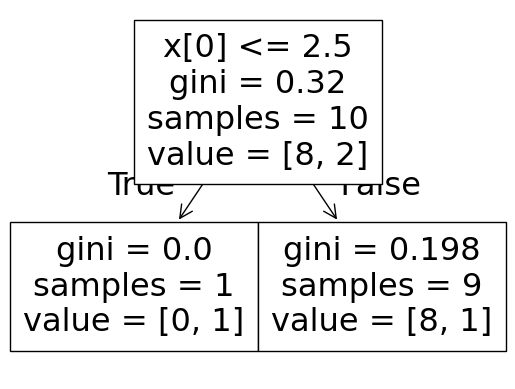

In [36]:
plot_tree(dt2)

### Visualise Stump 2 — Decision Boundary
Compare with stump 1 — the boundary may shift because the training data distribution changed.

<Axes: >

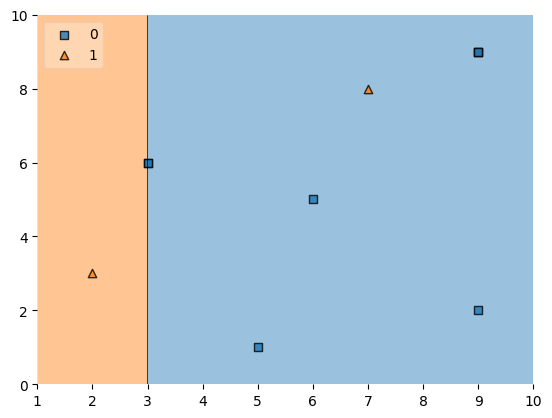

In [37]:
plot_decision_regions(X, y, clf=dt2, legend=2)

### Step 14: Get Stump 2 Predictions on second_df

In [38]:
second_df['y_pred'] = dt2.predict(X)

In [39]:
second_df

,X1,X2,label,weights,y_pred
2,3,6,0,0.1,0
8,9,9,0,0.1,0
6,6,5,0,0.1,0
1,2,3,1,0.1,1
8,9,9,0,0.1,0
8,9,9,0,0.1,0
4,5,1,0,0.1,0
2,3,6,0,0.1,0
9,9,2,0,0.1,0
7,7,8,1,0.1,0


### Step 15: Calculate Model Weight α₂
error = 0.1 here — stump 2 is much more accurate (only 1 in 10 wrong).
→ α₂ will be much higher than α₁ → stump 2 gets more say in the final vote.


In [40]:
alpha2 = calculate_model_weight(0.1)

In [41]:
alpha2

np.float64(1.0986122886681098)

### Step 16: Update Sample Weights for Iteration 3
Same formula as before — misclassified samples in second_df get heavier weights.

In [42]:
# Step 4 - Update weights
def update_row_weights(row,alpha=1.09):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [43]:
second_df['updated_weights'] = second_df.apply(update_row_weights,axis=1)

In [44]:
second_df

,X1,X2,label,weights,y_pred,updated_weights
2,3,6,0,0.1,0,0.033622
8,9,9,0,0.1,0,0.033622
6,6,5,0,0.1,0,0.033622
1,2,3,1,0.1,1,0.033622
8,9,9,0,0.1,0,0.033622
8,9,9,0,0.1,0,0.033622
4,5,1,0,0.1,0,0.033622
2,3,6,0,0.1,0,0.033622
9,9,2,0,0.1,0,0.033622
7,7,8,1,0.1,0,0.297427


### Step 17: Normalise Weights

In [45]:
second_df['nomalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()

In [46]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights
2,3,6,0,0.1,0,0.033622,0.056034
8,9,9,0,0.1,0,0.033622,0.056034
6,6,5,0,0.1,0,0.033622,0.056034
1,2,3,1,0.1,1,0.033622,0.056034
8,9,9,0,0.1,0,0.033622,0.056034
8,9,9,0,0.1,0,0.033622,0.056034
4,5,1,0,0.1,0,0.033622,0.056034
2,3,6,0,0.1,0,0.033622,0.056034
9,9,2,0,0.1,0,0.033622,0.056034
7,7,8,1,0.1,0,0.297427,0.495694


In [47]:
second_df['nomalized_weights'].sum()

np.float64(1.0)

### Step 18: Build Cumulative Sum for Next Bootstrap

In [48]:
second_df['cumsum_upper'] = np.cumsum(second_df['nomalized_weights'])

In [49]:
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['nomalized_weights']

In [50]:
second_df[['X1','X2','label','weights','y_pred','nomalized_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,nomalized_weights,cumsum_lower,cumsum_upper
2,3,6,0,0.1,0,0.056034,0.000000,0.056034
8,9,9,0,0.1,0,0.056034,0.056034,0.112068
6,6,5,0,0.1,0,0.056034,0.112068,0.168102
1,2,3,1,0.1,1,0.056034,0.168102,0.224136
8,9,9,0,0.1,0,0.056034,0.224136,0.280170
8,9,9,0,0.1,0,0.056034,0.280170,0.336204
4,5,1,0,0.1,0,0.056034,0.336204,0.392238
2,3,6,0,0.1,0,0.056034,0.392238,0.448272
9,9,2,0,0.1,0,0.056034,0.448272,0.504306
7,7,8,1,0.1,0,0.495694,0.504306,1.000000


---
## Iteration 3

### Step 19: Weighted Bootstrap → third_df
Sample from second_df using updated probabilities — the hard examples dominate even more.


In [51]:
index_values = create_new_dataset(second_df)

In [52]:
third_df = second_df.iloc[index_values,[0,1,2,3]]

In [53]:
third_df

,X1,X2,label,weights
9,9,2,0,0.1
9,9,2,0,0.1
9,9,2,0,0.1
2,3,6,0,0.1
8,9,9,0,0.1
2,3,6,0,0.1
2,3,6,0,0.1
8,9,9,0,0.1
6,6,5,0,0.1
2,3,6,0,0.1


### Step 20: Train Stump 3 (dt3) on the New Data

In [54]:
dt3 = DecisionTreeClassifier(max_depth=1)

X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

dt3.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

### Visualise Stump 3 — Decision Boundary

<Axes: >

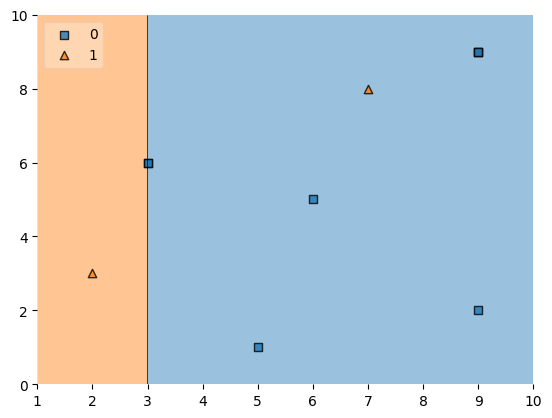

In [55]:
plot_decision_regions(X, y, clf=dt3, legend=2)

### Step 21: Get Stump 3 Predictions on third_df

In [56]:
third_df['y_pred'] = dt3.predict(X)

In [57]:
third_df

,X1,X2,label,weights,y_pred
9,9,2,0,0.1,0
9,9,2,0,0.1,0
9,9,2,0,0.1,0
2,3,6,0,0.1,1
8,9,9,0,0.1,0
2,3,6,0,0.1,0
2,3,6,0,0.1,0
8,9,9,0,0.1,0
6,6,5,0,0.1,0
2,3,6,0,0.1,0


### Step 22: Calculate Model Weight α₃
error = 0.7 → stump 3 is actually worse than random guessing (> 0.5).
→ α₃ will be **negative** — this stump's vote gets **flipped** in the ensemble.


In [58]:
alpha3 = calculate_model_weight(0.7)
alpha3

np.float64(-0.4236489301936017)

In [59]:
print(alpha1,alpha2,alpha3)

0.42364893019360184 1.0986122886681098 -0.4236489301936017


---
## Final Predictions — Weighted Vote

### How the Final Prediction Works
```
score(x) = α₁ × T₁(x) + α₂ × T₂(x) + α₃ × T₃(x)

  where  T(x) = +1 if predicted class 1
               -1 if predicted class 0

final class = sign(score)
  → +1 (positive) = class 1
  → -1 (negative) = class 0
```


### Query 1: x = [1, 5]
Test point at X1=1, X2=5 — predict class for this sample.

In [60]:
query = np.array([1,5]).reshape(1,2)
dt1.predict(query)

array([1])

In [61]:
dt2.predict(query)

array([1])

In [62]:
dt3.predict(query)

array([1])

**Weighted vote for [1, 5]:**
```
score = α₁×(+1) + α₂×(+1) + α₃×(+1)
```
All three stumps agree on class 1. Even if α₃ is negative, the sum determines the sign.


In [63]:
alpha1*1 + alpha2*(1) + alpha3*(1)

np.float64(1.09861228866811)

In [64]:
np.sign(1.09)

np.float64(1.0)

### Query 2: x = [9, 9]
Test point at X1=9, X2=9 — this is in the opposite region.

In [65]:
query = np.array([9,9]).reshape(1,2)
dt1.predict(query)

array([0])

In [66]:
dt2.predict(query)

array([0])

In [67]:
dt3.predict(query)

array([0])

**Weighted vote for [9, 9]:**
```
score = α₁×(+1) + α₂×(−1) + α₃×(−1)
```
Stumps 2 and 3 predict class 0 (mapped to -1). α₂ is large → they outweigh stump 1.


In [68]:
alpha1*(1) + alpha2*(-1) + alpha3*(-1)

np.float64(-0.2513144282809062)

In [69]:
np.sign(-0.25)

np.float64(-1.0)

---
## Summary

```
AdaBoost Manual Steps (3 Iterations):

  Init:   wᵢ = 1/N for all samples

  For each iteration t:
    1. Sample dataset by weights → new_df
    2. Train stump Tₜ on new_df
    3. Compute error = Σ wᵢ [yᵢ ≠ Tₜ(xᵢ)]
    4. Compute αₜ = 0.5 × ln((1-error)/error)
    5. Update weights:
         wᵢ ← wᵢ × exp(−αₜ)  if correct
         wᵢ ← wᵢ × exp(+αₜ)  if wrong
    6. Normalise weights (sum = 1)

  Final prediction = sign( Σ αₜ × Tₜ(x) )

Key insight:
  - Stumps with low error get high α → more say in the vote
  - Misclassified samples get higher weight → next stump focuses on them
  - sklearn: AdaBoostClassifier(n_estimators=50, learning_rate=1.0)
```
